In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [31]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
# features = ["game_completed", "relative_strength", "score_difference", "type.id", "home_has_possession", "end.down", "end.yardsToEndzone", "end.distance", "field_position_shift", "home_timeouts_left", "away_timeouts_left"]
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left"]
# features = ["relative_strength", "score_difference", "home_has_possession"]

/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML


In [32]:
# Reset the modules
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

import process_data
training_data = process_data.load_data(interpolated_dir, 
                                       years = [2016, 2017,2018, 2019, 2020, 2021, 2022, 2023], 
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win")

# validation_data = process_data.load_data(interpolated_dir, 
#                                        years = [2023], 
#                                        history_length = 0, 
#                                        features = features, 
#                                        label_feature = "home_win",
#                                        train = True
#                                        )

test_data = process_data.load_data(interpolated_dir, 
                                       years = [2024, 2025],
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win",
                                       train = False
                                       )


Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [3]:
# Load edge-case datasets (filter by timestep threshold and score_difference)
# Reload module to pick up the new function
modules_to_reload = [
    'process_data',
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
import process_data
# edge_featues = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down",  "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left"]
edge_threshold = 0.97  # minimum timestep to include (adjust as needed)
edge_training_data = process_data.load_edge_case_data(
    interpolated_dir,
    years=[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    history_length=0,
    features=features,
    label_feature='home_win',
    threshold=edge_threshold,
    train=True
)
edge_test_data = process_data.load_edge_case_data(
    interpolated_dir,
    years=[2024, 2025],
    history_length=0,
    features=features,
    label_feature='home_win',
    threshold=edge_threshold,
    train=False
)

print('Num train entries:', len(edge_training_data))
print('Num test entries:', len(edge_test_data))

/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [5]:
# Train a single LogisticRegressionModel on one timestep from the edge-case data
modules_to_reload = [
    'models.logistic_regression',
    'models.Model'
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
from models.logistic_regression import LogisticRegressionModel
from models.xg_boost import LightGBM
from sklearn.model_selection import train_test_split

# Define numeric/other features here so this cell is self-contained
edge_numeric_features = ["score_difference", "relative_strength", "end.yardsToEndzone", "end.distance"]
edge_other_features = ["home_has_possession", "end.down", "home_timeouts_left", "away_timeouts_left"]
# Define numeric/other features here so this cell is self-contained
edge_numeric_features = [
    "score_difference", 
    "relative_strength", 
    "end.yardsToEndzone", 
    "end.distance",
    "time_remaining_pct",
    "score_diff_x_time",
    "timeout_diff",
    "yards_to_fg_range"
]

edge_other_features = [
    "game_completed",
    "home_has_possession", 
    "end.down", 
    "home_timeouts_left", 
    "away_timeouts_left",
    "home_winning_with_ball",
    "home_winning_no_ball",
    "away_winning_with_ball",
    "away_winning_no_ball",
    "tied",
    "needs_fg_only",
    "needs_td_only",
    "needs_multiple_scores",
    "in_fg_range",     # Binary (0/1) - moved from numeric
    "in_red_zone"      # Binary (0/1) - moved from numeric
]

derived_features = [
    "home_winning_with_ball", "home_winning_no_ball",
    "away_winning_with_ball", "away_winning_no_ball",
    "tied", "time_remaining_pct", "score_diff_x_time",
    "needs_fg_only", "needs_td_only", "needs_multiple_scores",
    "timeout_diff", "yards_to_fg_range", "in_fg_range", "in_red_zone"
]

all_features = features + derived_features
# Choose timestep to train on (by default the largest available)
if not edge_training_data:
    raise ValueError("edge_training_data is empty")

# Prepare training data for selected timestep
X = np.array([entry["rows"].reshape(-1) for entry in edge_training_data])
y = np.array([entry["label"] for entry in edge_training_data])

# Instantiate and train the model
single_model = LogisticRegressionModel(
    numeric_features=edge_numeric_features,
    other_features=edge_other_features,
    all_features=all_features,
    use_calibration=False,
    optimize_hyperparams=False
)

xgboost_model = LightGBM(
    numeric_features=edge_numeric_features,
    other_features=edge_other_features,
    all_features=all_features,
    use_calibration=False,
    optimize_hyperparams=False 
)

single_model.fit(X, y)
print(X[1])
# Keep model in notebook namespace
edge_single_model = single_model
edge_single_model.predict_proba([X[1]])

: Training Loss = 0.4501, Accuracy = 0.7813, Test Loss = 0.4575, Test Accuracy = 0.8209
[ 9.6666664e-01  3.2910001e-01 -4.0000000e+00  0.0000000e+00
  1.0000000e+00  1.2000000e+01  3.4000000e+01  3.0000000e+00
  3.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00
  0.0000000e+00  0.0000000e+00  3.3333335e-02 -1.3333334e-01
  0.0000000e+00  1.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  1.0000000e+00  0.0000000e+00]


array([[0.93683951, 0.06316049]])

In [6]:
# Train a single DirectClassifier (neural network) on one timestep from the edge-case data
modules_to_reload = [
    'models.direct_prediction_network',
    'models.Model'
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

from models.direct_prediction_network import DirectPredictionNetwork, DirectClassifier
import torch
from torch import nn
from sklearn.model_selection import train_test_split

# Prepare training data (flatten rows to 2D)
X = np.array([np.asarray(entry['rows']).reshape(-1) for entry in edge_training_data], dtype=np.float32)
y = np.array([entry['label'] for entry in edge_training_data], dtype=np.float32)
# Train/validation split
if len(X) < 10:
    print(f"Too few samples ({len(X)}) - using all for training")
    X_train, y_train, X_val, y_val = X, y, None, None
else:
    unique, counts = np.unique(y, return_counts=True)
    stratify = y if (len(unique) > 1 and counts.min() >= 2) else None
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.10, random_state=42, stratify=stratify)

print(f"Prepared X_train shape: {X_train.shape}, X_val shape: {None if X_val is None else X_val.shape}")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Build network
input_dim = X.shape[1]
direct_net = DirectPredictionNetwork(input_dim=input_dim, hidden_dims=[64, 32, 16, 8], dropout_rate=0).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(direct_net.parameters(), lr=1e-3, weight_decay=1e-4)
 
# Instantiate classifier
direct_classifier = DirectClassifier(
    model=direct_net,
    epochs=50,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    features=all_features,  # uses same feature ordering as the dataset
    scheduler=None,
    use_scaler=True,
    optimize_hyperparams=False
)

# Train (classifier handles internal scaling and uses provided val set)
direct_classifier.fit(X_train, y_train, val_X=X_val, val_y=y_val, batch_size=64, verbose=True)

print("Direct classifier training finished.")
print("Train loss:", direct_classifier.final_train_loss)
print("Train accuracy:", direct_classifier.final_train_accuracy)
print("Val loss:", direct_classifier.final_val_loss)
print("Val accuracy:", direct_classifier.final_val_accuracy)

# Keep classifier in notebook namespace
edge_direct_classifier = direct_classifier

Prepared X_train shape: (6493, 23), X_val shape: (722, 23)
Starting training on device: cpu
Early stopping at epoch 29
Best epoch: 19, Train Acc: 0.8839, Train Loss: 0.2588, Val Acc: 0.8546, Val Loss: 0.3089
Restored model from best epoch 19 with val_loss: 0.308875
Direct classifier training finished.
Train loss: 0.25884978779975104
Train accuracy: 0.8838749422454951
Val loss: 0.3088750249395768
Val accuracy: 0.8545706371191135


In [20]:
# other_features = [
#             "type.id",             # Play type (categorical)
#             "home_has_possession", # Binary indicator
#             "end.down",            # Down number (1-4, discrete)
#             "home_timeouts_left",  # Discrete count (0-3)
#             "away_timeouts_left",  # Discrete count (0-3)
#             "game_completed"
#         ]
# numeric_features = [
#     "score_difference",
#     "relative_strength", 
#     "end.yardsToEndzone", 
#     "end.distance", 
#     "field_position_shift"
# ]
other_features = [
            "home_has_possession", # Binary indicator
            "end.down",            # Down number (1-4, discrete)
            "home_timeouts_left",  # Discrete count (0-3)
            "away_timeouts_left",  # Discrete count (0-3)
            "score_difference",
        ]
numeric_features = [
    "game_completed",
    "relative_strength", 
    "end.yardsToEndzone", 
    "end.distance"
]

In [8]:
class CombinedModel:
    def __init__(self, general_model, specialized_model, original_features, 
                 edge_numeric_features, edge_other_features, scaler=None, 
                 tight_threshold=7, late_game_threshold=0.95):
        """
        Args:
            general_model: Model trained on all game states
            specialized_model: Model trained on late/tight games with derived features
            original_features: List of original feature names
            edge_numeric_features: List of numeric features for specialized model (for normalization)
            edge_other_features: List of binary/categorical features for specialized model
            scaler: Fitted StandardScaler for edge numeric features (optional)
            tight_threshold: Score difference threshold for "tight game" (default 7)
            late_game_threshold: game_completed threshold for "late game" (default 0.95)
        """
        self.general_model = general_model
        self.specialized_model = specialized_model
        self.original_features = original_features
        self.edge_numeric_features = edge_numeric_features
        self.edge_other_features = edge_other_features
        self.scaler = scaler
        self.tight_threshold = tight_threshold
        self.late_game_threshold = late_game_threshold
        
        # Get feature indices from original features
        self.idx_score_diff = original_features.index("score_difference")
        self.idx_game_completed = original_features.index("game_completed")
        self.idx_home_poss = original_features.index("home_has_possession")
        self.idx_yards = original_features.index("end.yardsToEndzone")
        self.idx_home_to = original_features.index("home_timeouts_left")
        self.idx_away_to = original_features.index("away_timeouts_left")
        
    def _is_tight_late_game(self, row):
        """Check if this is a tight late-game situation."""
        score_diff = abs(row[self.idx_score_diff])
        game_completed = row[self.idx_game_completed]
        return (score_diff <= self.tight_threshold and 
                game_completed >= self.late_game_threshold)
    
    def _derive_features(self, row):
        """Derive additional features for specialized model from original features."""
        score_diff = row[self.idx_score_diff]
        game_completed = row[self.idx_game_completed]
        home_poss = row[self.idx_home_poss]
        yards = row[self.idx_yards]
        home_to = row[self.idx_home_to]
        away_to = row[self.idx_away_to]
        
        # Derived features
        home_winning = 1 if score_diff > 0 else 0
        away_winning = 1 if score_diff < 0 else 0
        tied = 1 if score_diff == 0 else 0
        
        home_winning_with_ball = home_winning * home_poss
        home_winning_no_ball = home_winning * (1 - home_poss)
        away_winning_with_ball = away_winning * (1 - home_poss)
        away_winning_no_ball = away_winning * home_poss
        
        time_remaining_pct = 1.0 - game_completed
        score_diff_x_time = score_diff * time_remaining_pct
        
        abs_score_diff = abs(score_diff)
        needs_fg_only = 1 if abs_score_diff <= 3 else 0
        needs_td_only = 1 if 3 < abs_score_diff <= 7 else 0
        needs_multiple_scores = 1 if abs_score_diff > 8 else 0
        
        timeout_diff = home_to - away_to
        
        yards_to_fg_range = max(0, yards - 37)
        in_fg_range = 1 if yards <= 37 else 0
        in_red_zone = 1 if yards <= 20 else 0
        
        derived = {
            "home_winning_with_ball": home_winning_with_ball,
            "home_winning_no_ball": home_winning_no_ball,
            "away_winning_with_ball": away_winning_with_ball,
            "away_winning_no_ball": away_winning_no_ball,
            "tied": tied,
            "time_remaining_pct": time_remaining_pct,
            "score_diff_x_time": score_diff_x_time,
            "needs_fg_only": needs_fg_only,
            "needs_td_only": needs_td_only,
            "needs_multiple_scores": needs_multiple_scores,
            "timeout_diff": timeout_diff,
            "yards_to_fg_range": yards_to_fg_range,
            "in_fg_range": in_fg_range,
            "in_red_zone": in_red_zone
        }
        return derived
    
    def _build_edge_features(self, row):
        """Build feature vector preserving all_edge_features order from training."""
        # Start with original features (already in row)
        feature_dict = {feat: row[self.original_features.index(feat)] 
                    for feat in self.original_features}
        
        # Add derived features
        derived = self._derive_features(row)
        feature_dict.update(derived)
        
        # Build feature vector in EXACT order of all_edge_features (training order)
        edge_features = []
        for feat in feature_dict.keys():
            edge_features.append(feature_dict[feat])
        
        edge_array = np.array(edge_features, dtype=np.float32).reshape(1, -1)
        return edge_array 
    
    def predict_proba(self, X):
        """Predict probabilities, using specialized model for tight late games."""
        result = []
        
        for row in X:
            if self._is_tight_late_game(row):
                # Build edge features and use specialized model
                edge_features = self._build_edge_features(row)
                pred = self.specialized_model.predict_proba(edge_features)[0]
            else:
                # Use general model
                pred = self.general_model.predict_proba(np.array([row]))[0]
            
            result.append(pred)
        
        return np.array(result)
    
    def predict(self, X):
        """Predict class labels."""
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)
    
    def score(self, X, y):
        """Calculate accuracy."""
        predictions = self.predict(X)
        return np.mean(predictions == y)

In [21]:
# Setup model for each timestep
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
# create an array of logistic regression models

modules_to_reload = [
    'models.logistic_regression',
    'models.Model'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
from models.Model import Model
from models.logistic_regression import setup_logistic_regression_models

models = setup_logistic_regression_models(training_data, None, numeric_features, other_features, features, optimize_hyperparams=False, use_calibration=False)


Processing timestep: 0.0
Timestep 0.00% : Training Loss = 0.6244, Accuracy = 0.6507, Test Loss = 0.6400, Test Accuracy = 0.6431
Processing timestep: 0.005
Timestep 0.50% : Training Loss = 0.6308, Accuracy = 0.6385, Test Loss = 0.6429, Test Accuracy = 0.6053
Processing timestep: 0.01
Timestep 1.00% : Training Loss = 0.6190, Accuracy = 0.6442, Test Loss = 0.6351, Test Accuracy = 0.6542
Processing timestep: 0.015
Timestep 1.50% : Training Loss = 0.6318, Accuracy = 0.6369, Test Loss = 0.6187, Test Accuracy = 0.6688
Processing timestep: 0.02
Timestep 2.00% : Training Loss = 0.6301, Accuracy = 0.6432, Test Loss = 0.6571, Test Accuracy = 0.6012
Processing timestep: 0.025
Timestep 2.50% : Training Loss = 0.6311, Accuracy = 0.6374, Test Loss = 0.6371, Test Accuracy = 0.6648
Processing timestep: 0.03
Timestep 3.00% : Training Loss = 0.6182, Accuracy = 0.6596, Test Loss = 0.6372, Test Accuracy = 0.6246
Processing timestep: 0.035
Timestep 3.50% : Training Loss = 0.6268, Accuracy = 0.6465, Test Los

In [23]:
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left"]

def is_close_to_scoring(row, home_has_possession, score_difference):
    yards_to_endzone = row[features.index("end.yardsToEndzone")]
    down = row[features.index("end.down")]

    # score_difference = home_score - away_score
    # if score_difference > 0: home is winning, away is trailing
    # if score_difference < 0: home is trailing
    if score_difference > 0:
        trailing_has_ball = (home_has_possession == 0)
    else:
        trailing_has_ball = (home_has_possession == 1)

    if not trailing_has_ball:
        return False

    # Trailing team has the ball - check field position
    in_td_range = yards_to_endzone <= 25
    in_fg_range = yards_to_endzone <= 40 and down >= 3
    return in_td_range or in_fg_range


def find_edge_cases(test_data, features, timestep_threshold=0.97, max_score_diff=7):
    """
    Extract edge cases from the test dataset.
    An edge case is an endgame play where:
      1. game_completed >= timestep_threshold (endgame)
      2. |score_difference| < max_score_diff (close game, strictly less than 7)
      3. The trailing team is close to scoring (heuristic based on field position)
    Returns a list of (feature_row, label, homeWinProbability) tuples.
    """
    edge_cases = []
    total = 0
    for timestep_key, entries in test_data.items():
        for entry in entries:
            total += 1
            row = entry["rows"]
            label = entry["label"]
            hwp = entry.get("homeWinProbability", None)

            game_completed = row[features.index("game_completed")]
            score_diff = row[features.index("score_difference")]
            home_poss = row[features.index("home_has_possession")]

            # Condition 1: endgame
            if game_completed < timestep_threshold:
                continue

            # Condition 2: close game (strictly less than 7 points difference)
            if abs(score_diff) >= max_score_diff:
                continue

            # Condition 3: trailing team is close to scoring
            if score_diff == 0:
                # Tied game: whoever has ball in scoring position is an edge case
                yards_to_endzone = row[features.index("end.yardsToEndzone")]
                down = row[features.index("end.down")]
                if not (yards_to_endzone <= 25 or (yards_to_endzone <= 40 and down >= 3)):
                    continue
            else:
                if not is_close_to_scoring(row, home_poss, score_diff):
                    continue

            edge_cases.append((row, label, hwp))

    return edge_cases, total


def predict_edge_cases(edge_cases, models, features):
    """
    Run inference on extracted edge cases.
    edge_cases: list of (feature_row, label, homeWinProbability)
    Prints P(home win), ESPN homeWinProbability, and ground truth label.
    """
    model_keys = sorted(models.keys())
    brier_sum = 0.0
    espn_brier_sum = 0.0
    n_features = len(features)

    for row, label, hwp in edge_cases:
        timestep = row[features.index("game_completed")]

        key = max((k for k in model_keys if k <= timestep), default=model_keys[0])
        model = models[key]

        # Use only the model features (first n_features values), exclude homeWinProbability
        feature_input = row[:n_features].reshape(1, -1)
        prob = model.predict_proba(feature_input)[0][1]
        brier_sum += (prob - label) ** 2

        hwp_str = f"{hwp:.4f}" if hwp is not None else "N/A"
        if hwp is not None:
            espn_brier_sum += (hwp - label) ** 2
        print(
            f"score_diff={row[features.index('score_difference')]:+.0f}  "
            f"home_poss={int(row[features.index('home_has_possession')])}  "
            f"yards_to_ez={row[features.index('end.yardsToEndzone')]:.1f}  "
            f"down={int(row[features.index('end.down')])}  "
            f"game_completed={row[features.index('game_completed')]:.3f}  "
            f"| P(Home win)={prob:.4f}  "
            f"ESPN={hwp_str}  "
            f"GT={label:.0f}"
        )

    brier_score = brier_sum / len(edge_cases) if edge_cases else float("nan")
    print(f"\n{'='*70}")
    print(f"Total edge cases found: {len(edge_cases)}")
    print(f"Brier Score (vs GT):    {brier_score:.4f}")
    print(f"ESPN Brier Score (vs GT): {espn_brier_sum / len(edge_cases) if edge_cases else float('nan'):.4f}")

# Find edge cases in the test dataset and run inference
edge_cases_from_test, total_edge_cases = find_edge_cases(test_data, features, timestep_threshold=0.97, max_score_diff=7)
print(f"Found {len(edge_cases_from_test)} edge cases in test data.")
print(f"Total test cases: {total_edge_cases}")
predict_edge_cases(edge_cases_from_test, models, features)


Found 660 edge cases in test data.
Total test cases: 148984
score_diff=+3  home_poss=0  yards_to_ez=2.0  down=2  game_completed=0.970  | P(Home win)=0.4999  ESPN=0.2705  GT=1
score_diff=+5  home_poss=0  yards_to_ez=1.0  down=2  game_completed=0.970  | P(Home win)=0.7645  ESPN=0.4119  GT=1
score_diff=+2  home_poss=0  yards_to_ez=27.0  down=3  game_completed=0.970  | P(Home win)=0.4596  ESPN=0.3788  GT=0
score_diff=+2  home_poss=0  yards_to_ez=20.0  down=1  game_completed=0.970  | P(Home win)=0.4139  ESPN=0.2911  GT=0
score_diff=+0  home_poss=1  yards_to_ez=15.0  down=-1  game_completed=0.970  | P(Home win)=0.5812  ESPN=0.4155  GT=0
score_diff=+6  home_poss=0  yards_to_ez=1.0  down=3  game_completed=0.970  | P(Home win)=0.7719  ESPN=0.6887  GT=1
score_diff=+6  home_poss=0  yards_to_ez=1.0  down=2  game_completed=0.970  | P(Home win)=0.7616  ESPN=0.4802  GT=1
score_diff=+0  home_poss=1  yards_to_ez=23.0  down=1  game_completed=0.971  | P(Home win)=0.6361  ESPN=0.8125  GT=1
score_diff=+0  

In [10]:
def replace_model(models, specialized_model, original_features, 
                 edge_numeric_features, edge_other_features, edge_scaler,
                 threshold=0.95, tight_threshold=7):
    """
    Replace models after a certain threshold with CombinedModel that uses specialized model for edge cases.
    
    Args:
        models: Dict of {timestep: model} 
        specialized_model: The edge-case specialized model
        original_features: List of original feature names
        edge_numeric_features: List of numeric features for specialized model
        edge_other_features: List of binary/categorical features for specialized model
        edge_scaler: Fitted StandardScaler for edge numeric features
        threshold: Timestep threshold above which to use CombinedModel (default 0.95)
        tight_threshold: Score difference threshold for "tight game" (default 7)
    
    Returns:
        new_models: Dict with CombinedModel for timesteps >= threshold
    """
    new_models = {}
    
    for key, general_model in models.items():
        if key >= threshold:
            # Wrap with CombinedModel that can route to specialized model
            new_models[key] = CombinedModel(
                general_model=general_model,
                specialized_model=specialized_model,
                original_features=original_features,
                edge_numeric_features=edge_numeric_features,
                edge_other_features=edge_other_features,
                scaler=edge_scaler,
                tight_threshold=tight_threshold,
                late_game_threshold=threshold  # Use same threshold for consistency
            )
        else:
            # Keep original model for early/mid-game
            new_models[key] = general_model
    
    return new_models
# Usage:
new_models = replace_model(
    models=models,
    specialized_model=edge_single_model,
    original_features=features,
    edge_numeric_features=edge_numeric_features,
    edge_other_features=edge_other_features,
    edge_scaler=None,
    threshold=0.95,
    tight_threshold=7
)

In [11]:
print(models[0.99])
print(new_models[1])

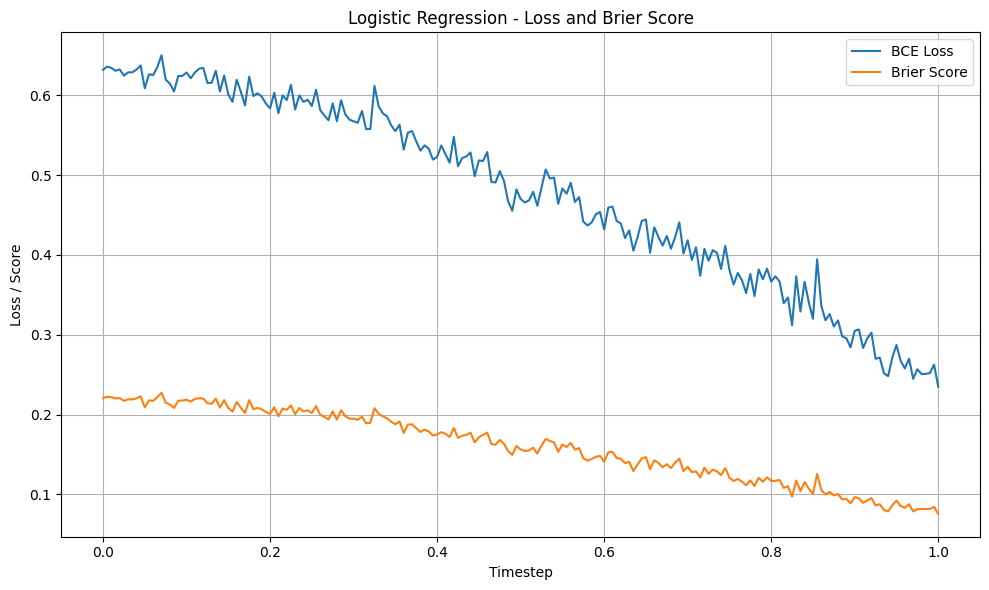

In [30]:
# # Test accuracy of model for each timestep on test data and plot
# accuracies = []
# timesteps = []
import process_data
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

x = process_data.plot_loss(models, test_data, "Logistic Regression")
# process_data.plot_accuracy(models, test_data, "Logistic Regression")
# process_data.plot_loss(new_models, test_data, "Logistic Regression")

In [ ]:
model = models[0.99]
# features = ["relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone",  "home_timeouts_left", "away_timeouts_left"]
data_point = [0.99, 0.5, -1, 1, 1, 1, 1, 1, 1]
model.predict_proba(np.array([data_point]))

In [156]:
# Save the model
import pickle
filename = 'logistic_regression_model.pickle'
pickle.dump(models, open(filename, 'wb'))

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
%reload_ext autoreload
from models.utils import SHAP_analysis
# model = models[0.99]
# # Health Check:
# if hasattr(model.model, "coef_"):
#     feature_names = model.all_features if hasattr(model, "all_features") else None
#     coefs = model.model.coef_[0]  # shape (n_features,)
#     if feature_names is not None and len(feature_names) == len(coefs):
#         for name, coef in zip(feature_names, coefs):
#             print(f"{name}: {coef}")

SHAP_analysis(models, training_data, test_data, "logistic_regression", "shap_values/LR_possession_probs", timesteps_size=0.1, num_threads = 5)
# x = np.array([[0.1, 0.9, 20, 1, 0, 1, 50, 20, 2, 2, 2]])
# model.predict_proba(x)


Processing 20 timesteps (skipping 0 already done, 181 not selected).


ExactExplainer explainer:  92%|█████████▏| 506/552 [00:00<?, ?it/s]





ExactExplainer explainer:  93%|█████████▎| 512/552 [00:10<00:00, 57.86it/s]





ExactExplainer explainer:  94%|█████████▍| 518/552 [00:10<00:00, 50.92it/s]





ExactExplainer explainer:  95%|█████████▍| 524/552 [00:10<00:00, 49.42it/s]



ExactExplainer explainer:  96%|█████████▌| 529/552 [00:10<00:00, 45.48it/s]

ExactExplainer explainer:  97%|█████████▋| 538/552 [00:10<00:00, 58.66it/s]





ExactExplainer explainer:  99%|█████████▊| 545/552 [00:10<00:00, 55.85it/s]








ExactExplainer explainer: 100%|█████████▉| 551/552 [00:10<00:00, 49.12it/s]


ExactExplainer explainer: 553it [00:11,  4.25it/s]                         














Saved logistic_regression_0.0.npz

















































































































































































































































































































































































































ExactExplainer explainer:  44%|████▍     | 253/573 [00:00<?, ?it/s]





ExactExplainer explainer:  45%|████▍     | 257/573 [00:10<00:09, 32.88it/s]







ExactExplainer explainer:  46%|████▌     | 261/573 [00:10<00:14, 22.22it/s]




ExactExplainer explainer:  46%|████▌     | 265/573 [00:10<00:12, 24.98it/s]




ExactExplainer explainer:  47%|████▋     | 268/573 [00:10<00:12, 23.68it/s]










ExactExplainer explainer:  47%|████▋     | 271/573 [00:10<00:14, 21.42it/s]





ExactExplainer explainer:  48%|████▊     | 274/573 [00:10<00:14, 20.24it/s]





ExactExplainer explainer:  48%|████▊ 

Saved logistic_regression_0.05.npz


...

Saved logistic_regression_0.84.npz


ExactExplainer explainer:  22%|██▏       | 264/1176 [00:12<00:30, 30.01it/s]


ExactExplainer explainer:  23%|██▎       | 268/1176 [00:12<00:27, 32.62it/s]


ExactExplainer explainer:  23%|██▎       | 273/1176 [00:12<00:24, 36.35it/s]


ExactExplainer explainer:  24%|██▎       | 279/1176 [00:12<00:21, 42.53it/s]


ExactExplainer explainer:  24%|██▍       | 285/1176 [00:12<00:18, 46.91it/s]


ExactExplainer explainer:  25%|██▍       | 290/1176 [00:12<00:20, 42.32it/s]


ExactExplainer explainer:  25%|██▌       | 295/1176 [00:12<00:20, 43.28it/s]


ExactExplainer explainer:  26%|██▌       | 300/1176 [00:13<00:22, 39.79it/s]


ExactExplainer explainer:  26%|██▌       | 305/1176 [00:13<00:24, 35.70it/s]


ExactExplainer explainer:  26%|██▋       | 309/1176 [00:13<00:24, 34.89it/s]


ExactExplainer explainer:  27%|██▋       | 313/1176 [00:13<00:24, 35.23it/s]


ExactExplainer explainer:  27%|██▋       | 319/1176 [00:13<00:21, 40.01it/s]


ExactExplainer explainer:  28%|██▊       | 324/1176 

Saved logistic_regression_0.945.npz


ExactExplainer explainer: 1177it [00:25, 38.41it/s]                           


Saved logistic_regression_1.0.npz


In [169]:
class HeuristicNFLModel:
    """
    Heuristic-based NFL win probability model using domain knowledge and situational logic.
    """
    
    def __init__(self, features):
        """
        Args:
            features: List of feature names in order
        """
        self.features = features
        self.idx = {feat: i for i, feat in enumerate(features)}
        
    def _sigmoid(self, x, scale=1.0):
        """Smooth sigmoid function."""
        return 1.0 / (1.0 + np.exp(-x / scale))
    
    def _expected_points_from_position(self, yards_to_endzone, down, distance):
        """
        Estimate expected points for the possessing team from current position.
        Based on historical NFL analytics.
        """
        # Field position value (closer to opponent endzone = better)
        if yards_to_endzone <= 10:  # Inside 10
            base_ep = 6.0
        elif yards_to_endzone <= 20:  # Red zone
            base_ep = 4.5
        elif yards_to_endzone <= 40:  # Good field position
            base_ep = 3.0
        elif yards_to_endzone <= 60:  # Midfield area
            base_ep = 2.0
        elif yards_to_endzone <= 80:  # Own territory
            base_ep = 1.0
        else:  # Backed up
            base_ep = 0.3
        
        # Down and distance penalty
        if down == 1:
            down_multiplier = 1.0
        elif down == 2:
            down_multiplier = 0.9 if distance <= 7 else 0.7
        elif down == 3:
            down_multiplier = 0.7 if distance <= 5 else 0.4
        else:  # 4th down
            down_multiplier = 0.2 if distance <= 3 else 0.05
        
        return base_ep * down_multiplier
    
    def _time_value(self, game_completed, score_diff, has_possession):
        """
        Adjust for time remaining and possession.
        Returns multiplier for score difference impact.
        """
        time_remaining = 1.0 - game_completed
        
        # Late game: time becomes critical
        if game_completed > 0.95:  # Final ~3 minutes
            if has_possession and score_diff > 0:
                # Leading with ball late = can run clock
                return 1.5
            elif not has_possession and score_diff < 0:
                # Trailing without ball late = desperate
                return 0.6
        
        return 1.0
    
    def _calculate_win_prob(self, row):
        """Calculate win probability for a single game state."""
        # Extract features
        game_completed = row[self.idx['game_completed']]
        relative_strength = row[self.idx['relative_strength']]
        score_diff = row[self.idx['score_difference']]
        home_has_poss = row[self.idx['home_has_possession']]
        down = row[self.idx['end.down']]
        distance = row[self.idx['end.distance']]
        yards = row[self.idx['end.yardsToEndzone']]
        home_to = row[self.idx['home_timeouts_left']]
        away_to = row[self.idx['away_timeouts_left']]
        
        time_remaining = 1.0 - game_completed
        
        # === Early Game (first 40%) ===
        if game_completed < 0.40:
            # Mostly rely on pre-game strength with small score adjustment
            base_prob = relative_strength
            score_adjustment = self._sigmoid(score_diff, scale=14.0) - 0.5
            return np.clip(base_prob + 0.2 * score_adjustment, 0.01, 0.99)
        
        # === Mid Game (40-85%) ===
        if game_completed < 0.85:
            # Balance pre-game strength and current score
            strength_weight = 0.3
            score_weight = 0.7
            
            base_prob = strength_weight * relative_strength + \
                       score_weight * self._sigmoid(score_diff, scale=10.0)
            
            return np.clip(base_prob, 0.01, 0.99)
        
        # === Late Game (85-95%) ===
        if game_completed < 0.95:
            # Score difference dominates, with possession mattering more
            base_prob = self._sigmoid(score_diff, scale=7.0)
            
            # Possession adjustment based on field position
            if home_has_poss:
                ep = self._expected_points_from_position(yards, down, distance)
                poss_adjustment = ep / 40.0  # Scale to reasonable range
            else:
                ep = self._expected_points_from_position(yards, down, distance)
                poss_adjustment = -ep / 40.0
            
            return np.clip(base_prob + poss_adjustment, 0.01, 0.99)
        
        # === Critical Final Minutes (95%+) ===
        # This is where heuristics really matter
        
        # 1. Check if game is essentially over
        seconds_left = time_remaining * 3600  # Approximate seconds
        
        # Leading team can kneel out clock?
        if score_diff > 0 and home_has_poss:
            # Home leading with ball
            kneels_possible = home_to + away_to + 3  # Timeouts + 3 kneels
            time_to_kneel = kneels_possible * 40
            if seconds_left < time_to_kneel and down < 4:
                return 0.995  # Game essentially over
        
        if score_diff < 0 and not home_has_poss:
            # Away leading with ball
            kneels_possible = home_to + away_to + 3
            time_to_kneel = kneels_possible * 40
            if seconds_left < time_to_kneel and down < 4:
                return 0.005  # Home has essentially lost
        
        # 2. Score difference analysis
        abs_score_diff = abs(score_diff)
        
        # Multiple score game (>8 points)
        if abs_score_diff > 8:
            if score_diff > 0:
                return 0.98 if home_has_poss else 0.95
            else:
                return 0.02 if not home_has_poss else 0.05
        
        # 3. Single-score game analysis (most complex)
        # This is where possession + field position + timeouts matter most
        
        # Calculate expected points for possessing team
        if home_has_poss:
            home_ep = self._expected_points_from_position(yards, down, distance)
            away_ep = 0  # Don't have ball
        else:
            home_ep = 0
            away_ep = self._expected_points_from_position(yards, down, distance)
        
        # Estimate possessions remaining (very rough)
        possessions_left = max(1, time_remaining * 8)  # ~8 possessions per game
        
        # Timeout advantage
        timeout_advantage = (home_to - away_to) * 0.02
        
        # Build probability from components
        if abs_score_diff <= 3:  # Field goal game
            # Need to reach FG range (approximately 35 yards from endzone)
            if home_has_poss:
                can_kick_fg = 1.0 if yards <= 35 else 0.5
                home_scoring_prob = can_kick_fg * 0.7  # ~70% FG success
            else:
                home_scoring_prob = 0.3  # Need to get ball back and score
            
            if score_diff == 0:  # Tied
                base_prob = 0.5 + (home_scoring_prob - 0.35)
            elif score_diff > 0:  # Home leading by FG
                base_prob = 0.65 if home_has_poss else 0.55
            else:  # Home trailing by FG
                base_prob = 0.35 if home_has_poss else 0.45
        
        elif abs_score_diff <= 7:  # Touchdown game
            if score_diff > 0:  # Home leading by TD
                if home_has_poss:
                    # Can run clock, away needs stop + TD drive
                    base_prob = 0.75
                else:
                    # Away has ball, needs TD to tie
                    if yards <= 50:  # Good field position
                        base_prob = 0.60
                    elif yards <= 80:  # Decent position
                        base_prob = 0.70
                    else:  # Backed up
                        base_prob = 0.80
            else:  # Home trailing by TD
                if home_has_poss:
                    # Home needs TD to tie
                    if yards <= 50:
                        base_prob = 0.40
                    elif yards <= 80:
                        base_prob = 0.30
                    else:
                        base_prob = 0.20
                else:
                    # Away has ball, can run clock
                    base_prob = 0.25
        else:
            # Shouldn't hit this, but fallback
            base_prob = self._sigmoid(score_diff, scale=7.0)
        
        # Apply timeout adjustment
        base_prob += timeout_advantage
        
        # Apply pre-game strength (small influence)
        base_prob = 0.9 * base_prob + 0.1 * relative_strength
        
        return np.clip(base_prob, 0.01, 0.99)
    
    def predict_proba(self, X):
        """
        Predict win probabilities.
        
        Args:
            X: Array of shape (n_samples, n_features)
            
        Returns:
            Array of shape (n_samples, 2) with [P(away_win), P(home_win)]
        """
        n_samples = len(X)
        probs = np.zeros((n_samples, 2))
        
        for i, row in enumerate(X):
            home_win_prob = self._calculate_win_prob(row)
            probs[i, 0] = 1 - home_win_prob  # Away win
            probs[i, 1] = home_win_prob      # Home win
        
        return probs
    
    def predict(self, X):
        """Predict class labels (0 = away win, 1 = home win)."""
        probs = self.predict_proba(X)
        return (probs[:, 1] >= 0.5).astype(int)
    
    def score(self, X, y):
        """Calculate accuracy."""
        predictions = self.predict(X)
        return np.mean(predictions == y)

In [70]:
modules_to_reload = [
    "process_data"
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
import process_data
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_prob_0_2pts", "predicted_drive_points_prob_3_6pts", "predicted_drive_points_prob_7plus_pts"]
class myModel:
    def __init__(self):
        pass
    def predict_proba(self, X):
        return np.array([[0.5, 0.5] for _ in X])
t = 0.97
process_data.assess_differences(new_models, test_data, t, features, threshold=0.02, alt_model=models[t])

309
-0.018992848529760534
-0.012637426715417514
     game_completed  relative_strength  score_difference  home_has_possession  end.down  end.distance  end.yardsToEndzone  home_timeouts_left  away_timeouts_left  label  predicted  alt_predicted    ESPN      diff
0          0.968333             0.5147              -1.0                  0.0       1.0          10.0                70.0                 3.0                 2.0    1.0   0.104827       0.242624  0.4577 -0.507246
1          0.968333             0.5147              -1.0                  0.0      -1.0          10.0                65.0                 3.0                 2.0    1.0   0.096606       0.242624  0.4082 -0.465893
2          0.968889             0.5220               0.0                  0.0       1.0          10.0                67.0                 1.0                 2.0    1.0   0.329978       0.320918  0.6831 -0.348505
3          0.968056             0.4433              -1.0                  1.0       1.0           9.

In [13]:
from process_data import write_predictions
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
write_predictions(models, interpolated_dir, [2024, 2025], 0, features, replace_nan_val = 0, phat_b = "LR_phat_b")

Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [14]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_11", "LR_model")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        folder_name = os.path.basename(source)
        
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_11/LR_model'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_11/LR_model'
